# Lecture 7: Fundamentals of Control Theory

In today's lecture, as requested, I will talk about Control Theory and how we can apply it on Dynamical and Stochastic Dynamical Systems. Before starting I want to make some important disclaimers:

1. I will not show to you any mathematical validity of what I'm saying today.
2. I am myself an user more than a theorist of this field so I will show you only the operative aspect.
3. The gergon and the name of the things in this field is extremely different from subfield to subfield and even from group to group.

After this premises we can start! 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.integrate as deqsol
import copy as copy

## 1. General Ideas

First of all: **what is the Control Theory?** Or better, what we are talking about when we are working with Control Theory in Dynamical Systems?

Given a Dynamical System it is usually characterize by a set of parameters $\bar{\theta}=\{\theta_1,...,\theta_k,\theta_{k+1},...,\theta_{n}\}$ which are able to determine the behaviours (both transient and SS) and the bifurcations of its own variables $\bar{x}(t)=\{x_1(t),...,x_m(t)\}$. Generally speaking, the objective of the Control Theory is to find a way to induce a desire behaviour in the system variables both in a transient and in a steady state framework. 

The starting idea is that, given our real-world counterpart of the system, we can identify a subset of parameters that can be adjusted by us in some way and some extention $\bar{\theta}_r=\{\theta_{k+1},...,\theta_n\}$. Therefore what we want now is to find good values for this parameters to achieve what we want in term of variables behaviour. Here we have to make our first choice: what kind of control schedule we want to apply?

Here the gergon starts to differ a lot from situation to situation but we can usually divide the general control schedule in 3 macro-families:

- **Open Loop Control**: no predefine control, checking step by step during the simulation looking only at the input and act according to a prefixed routine.
- **Static Optimal Control**: find the best possible parameters values and keeping it fixed in the simulation.
- **Dynamic Optimal Control**: find the best possible parameters values or fixed metaparameters to make them vary in time.

Obviously the 3 families add complexity and allows better and better control on the system. In other subfields there are also other categories but today we will only look at these and in particular on the last two categories. An example is, when having important noises, to mix the dynamical control to some open loop in case of a too strong stochastic fluctuation. But we can make an example to understand better the differences:

### Heating a room

We want to heat up a room from 20°C to 25°C using a regulable heater. We can use 3 different schedule to obtain this task:

- **OPEN LOOP**: We set a function: "if T<22°C then turn on at full power for 30 minutes". So our heater will turn on and work for 30 minutes. We don't know if it is enough, it could happen that the temperature will go above 25°C or stay between 22°C and 25°C.
- **STATIC OPTIMAL CONTROL**: Studying the system we discover that in our situation if we set a $60\%$ the power we will be able to keep a constant temperature (equilibrium) of 25°C thus we simply set the heater with a fixed value of $60\%$ and we wait for the system to move from 20°C to 25°C.
- **DYNAMIC OPTIMAL CONTROL**: Knowing the $60\%$ thing we can adapt a schedule with higher power at the beginning that progressivly tends to $60\%$ to speed up the initial heating phase.

We can focus now with the static optimal control and we will apply it to our Harvest Process in a deterministic framework for now.

## 2. Static Optimal Control

Let's start to look at how to perform an Optimal Control on a system. In this lecture we will work with an extremely easy case that could be almost be done by hand but it is useful for us that we do not have too much time. Let's consider the deterministic version of the Harvest Process:

$$
\frac{dx}{dt}=\alpha x(1-x)-kx
$$

If we think about our real world case, we are not truly able to control efficiently the growth factor of the forest $\alpha$ (at least if we don't want to destroy it) but it is much more controlable the cutting rate $k$ thus it will be our control parameter. 

To control it we will use the math of the Control Theory which is extremely similar to the statistical inference or the learning process in ML even if with some extra conditions and steps and, obviously, without reference data. This aspect of being incredibly similar is well expressed in a more theoretical way by the principle of the "Kalman's Duality" that in some way assess that Control Theory and Statistical Inference are like two faces of the same coin. 

Now we need to understand what is our desired behaviour and then we will have to convert it in some mathematical means. Let's suppose that we want to preserve as much as possible our forest but we don't want that the woodcutting activities go bankrupt therefore we cannot fix $k=0$ but we need to find a good in-between value. This gives us the first tool that we need to use which is the **loss function**. We don't have data to compare as in statistic but we want to create a function that express our will and that we want to minimize (or maximize as in the following case). A good solution could be something like this: given a trajectory of 100 days

$$
J=\int_0^T kx(t)dt-\lambda(k-k^*)
$$

where $k^*$ is obtained by the acceptable tree densities that the state would like in this forest (e.g. $80\%\rightarrow k^*=0.2$). Let's suppose also that according by law we cannot go above to $k=0.5$. This is another mathematical mean that is called **constrain**. In this case is easy to impose because we can simply set the available domain for $k$ to this limit but in more complex situation it is usually treated adding an enormous value to $J$ if it is broken.

In this case we can try to solve it analytically. The Harvest process above has solution:

$$
x(t)=\frac{\alpha-k}{\alpha+Ce^{-(\alpha-k)t}}\qquad where \qquad C(x_0)=\frac{a(1-x_0)-k}{x_0}
$$

It is also very easily integrable for the loss obtaining that

$$
I(t)=\frac{k}{a}\left(\ln(ae^{rt}+C)+B\right)
$$

Where $B$ can be determine posing that the gain at the beggining was 0. Therefore in this case, using then some graphical or numerical means, it is possible to find which is the value for $k$ in the domain able to maximize the loss function $J$. However, although this case is quite doable the situation becomes more and more difficult. We need to find another way...

The idea is to use some euristic methods to find the best value of the parameters. Now, there are tons of possibilities most of them equivalent under a general point of view but actually quite different in term of performaces from problem to problem. Most of the time it is anything but simple to understand which is the best thus in research a lot of people tries and purposes different algorithms for the same problem and makes comparison on the results. Today I will simply use a very simple algorithm which is one of the Population Based algorithms and it is called Particle Swarm Optimization.

The PSO is one of the most known and common method. It is not the best in every situation but it is generally good among the different kind of problems. This method has tons of children with some mods to adapt it to different situations. The idea is fairly simple: given the domain of the parameters we can control we:

0. Take a set of 20-50 values for the parameters
1. Produce a trajectory for every one of them
2. Evaluate the loss function
3. Check if the value is the best value found by the particle ($pbest$), if it is overwrite it.
4. Check which is the global best value among the personal bests.
5. Update velocity of the particle as:
   $$
   v_i^{t+1}=wv_i^t+c_1r_1(pbest_i-x_i^t)+c_2r_2(gbest-x_i^t)
   $$
   with $w$ the inertia parameter, $c_1,c_2$ some weights and $r_1,r_2$ random generated causality factors.
6. Update position as $x_i^{t+1}=x_i+v_i^{t+1}$
7. Repeat until a convergence condition is satisfy.

Let's try it for our problem. Let's pose some standard value for the parameters such as $w=0.6$, $c_1=c_2=0.1$ while $r_1,r_2=Unif([0,1])$ and $N=50$ particles. $c_1,c_2$ must be set small due to the domain, it is not the cleanest solution (due to the impact on variability) but is ok for us. Usually finding the right meta-parameters (the one of the euristic method) is not so simple and it is almost an art or a very experience-based task.

For the trajectory making we can copy the old code for the simulation adapting to the fully deterministic case.

In [2]:
class Harvest(object):

    #CONSTRUCTOR:
    def __init__(self,a: float,k: float)->None:
        #First let's check the inputs
        if(a<0 or k<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        return

    #This function is used to change the value of the params between a iteration and another
    def setParam(self,a: float,k: float)->None:
        '''
        This function recieve new values for the parameters (a,k)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0 or k<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: self._a*x*(1-x)-self._k*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART

        return traj

And now we can make a parameter's set manager that can help us to keep track of everything. Let's pose $\lambda=5$ and $k^*=0.2$.

In [3]:
class PSO_Manager(object):

    #CONSTRUCTOR
    def __init__(self,N: int,w: float,c1: float,c2: float)->None:
        #Let's check the input
        if(N<=0):
            raise RuntimeError("The number of particles must be positive.")
        if(w<0 or c1<0 or c2<0):
            raise RuntimeError("The parameters of the PSO must be non negative.")

        self._N = N
        self._w = w
        self._c1 = c1
        self._c2 = c2
        
        self.k_values = np.zeros(N,dtype=float)
        for i in range(self._N): #GENERATE INITIAL K VALUES BETWEEN 0 AND 1
            self.k_values[i] = random.uniform(0,0.5)

        self.loss_values = -1e30*np.ones(N,dtype=float)
        self.pbest_values = copy.copy(self.k_values)
        self.v_values = np.zeros(N,dtype=float)

        self._lambda = 5 #This parameter is for the loss and it is fundamental!!!!!!!
        self._k_star = 0.2

        self._var_counter = 0
        
        return

    #Given a trajectory compute the loss function and look if it is the personal best
    def checkLoss(self,T: np.array,index: int,h: float)->None:
        '''
        Given the trajectory, the index related to the k value
        and the step length, this function will compute the loss. 
        '''
        #We need to compute the loss as first thing
        loss = -self._lambda*(self.k_values[index]-self._k_star)

        I_val = 0
        for i in range(len(T)):
            I_val += T[i]*h
        I_val *= self.k_values[index]

        loss += I_val

        #Then check if it is the personal best and substitute if it is
        if(loss>=self.loss_values[index]):
            self.loss_values[index] = loss
            self.pbest_values[index] = self.k_values[index]

        return

    #This function it is used to make the new generation of values
    def evolveValues(self)->None:
        '''
        Computed the loss values of a generation, this function will
        produce the new gen using the PSO update rules.
        '''
        gbest = np.argmax(self.loss_values)
        gbest = self.k_values[gbest]

        for i in range(self._N):
            self.v_values[i] = self._w*self.v_values[i]
            self.v_values[i] += self._c1*random.uniform(0,1)*(self.pbest_values[i]-self.k_values[i])
            self.v_values[i] += self._c2*random.uniform(0,1)*(gbest-self.k_values[i])
            self.k_values[i] += self.v_values[i]

        return

    #This function will check the variance condition
    def exitCondition(self,index: int)->bool:
        '''
        Given the actual generation index, if enough generation passed,
        this system will check the variance condition and check if it
        is still valid.
        '''
        #1. Check if the number of q generation at least occured.
        if(index<40):
            return True

        if(np.var(self.loss_values)/np.mean(self.loss_values)<=0.01):
            self._var_counter += 1

        if(self._var_counter==40):
            print("Exited through variance condition")
            return False

        if(index==300): #Max iteration exit
            print("Exited through maximum iteration")
            return False

        return True

An important thing we need to discuss is the initial condition. If we want to treat it in a fully deterministic idea we MUST to keep it constant otherwise the system is stochastic. In fact having random initial condition makes it stochastic not under the "Ito perspective" but under the "Liouville perspective" (stochastic systems but with deterministic dynamic), which is still stochastic. Most probably for this kind of convergent situation with a single possible steady state is irrelevant and the behaviour will coincide more or less but it is not general valid. We will talk about how to control stochastic systems later.

Another thing we need absolutely to talk about is the stopping condition: after how many generations we stop? Is it fixed or it is a condition on the loss? Usually in every situation there is at least a sort of exit condition purely based on the number of iterations but there is always defined an exit based on the trend of the loss function. There are several possibilities but ofter the two most common type are:

- "Stagnation of the best" condition: gbest is not improving anymore (e.g. if we are at generation $M$, we look at the generation $M-p$ and check if the relative difference between the two is less than 5%) and this is a treng (e.g. if it is below 5%, we increase a counter then for the next $q$ generations we do the same. If it is still valid we exit).
- "Variance of the loss" condition: we compute the relative variance in the loss of the set if it is below a threshold and, if it is valid for the following $q$ generations, we exit.

However there are many more and often are present multiple condition both in a AND or in a OR relationship. We have implemented the variance one with $q=40$ and threshold equal to $1\%$ and the maximum iteration with cap at 300.

In [4]:
Nsim = 50

pso = PSO_Manager(Nsim,0.6,0.1,0.1)
system = Harvest(1.0,0.3) #0.3 is a placeholder
gbest = -1e30

#GEN 0: loss estimation
for j in range(Nsim):
    system.setParam(1.0,pso.k_values[j])
    traj = system.computeTraj(100,0.1,0.9)
    pso.checkLoss(traj,j,0.1)

gen_counter = 0

while(pso.exitCondition(gen_counter)):
    #1. Evolve the set in the new points:
    pso.evolveValues()

    #2. Compute the new losses
    for j in range(Nsim):
        system.setParam(1.0,pso.k_values[j])
        traj = system.computeTraj(100,0.1,0.9)
        pso.checkLoss(traj,j,0.1)

    gen_counter += 1

Exited through variance condition


Let's check the results and the best!

In [5]:
print(pso.k_values)

index = np.argmax(pso.loss_values)
print(pso.k_values[index])

[0.28468521 0.28468524 0.28468514 0.28468524 0.28468524 0.28468524
 0.28468526 0.28468524 0.28468525 0.28468524 0.28468524 0.28468524
 0.28468524 0.28468524 0.28468524 0.28468525 0.28468524 0.28468524
 0.28468525 0.28468524 0.28468523 0.28468524 0.28468524 0.28468524
 0.28468524 0.28468524 0.28468524 0.28468524 0.28468524 0.28468535
 0.28468524 0.28468524 0.28468524 0.28468524 0.28468524 0.28468524
 0.28468525 0.28468524 0.28468524 0.28468524 0.28468522 0.28468509
 0.28468483 0.28468525 0.28468525 0.28468524 0.28468524 0.28468524
 0.28468524 0.28468526]
0.2846852384161495


We can now try to see what happens if we use this value!

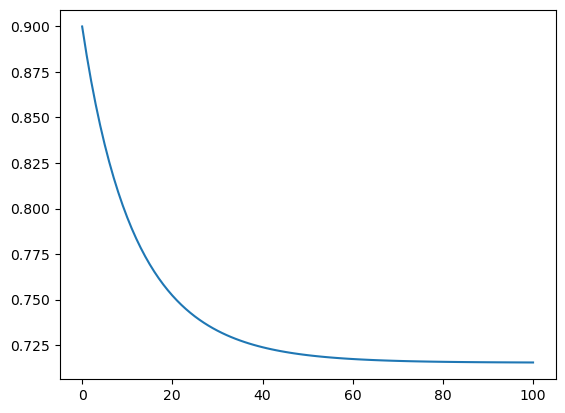

In [6]:
system = Harvest(1.0,0.28468524155449765)
t = system.computeTraj(100,0.1,0.9)

plt.plot(t)

## 3. Static Optimal Control in a stochastic situation

If the problem we are working on is stochastic we need to adjust our method to be able to treat it. Let's suppose now that we have random initial condition in $[0.5,0.95]$ and to have a Stochastic Harvest Process with $s=0.1$ defined as before

$$
dx = \left(\alpha x(1-x)-kx\right)dt+sx(1-x)dW
$$

The system is now stochastic and this increase quite a lot the complexity of our problem. Different trajectories have now different values of the loss so we need to decide how to estimate the quality of a certain parameters $k$. The fundamental idea are, as immaginable, repetitions: for each value of the parameters we make $N_{rep}$ repetitions and then define the associated loss as the mean of the losses. This opens up however tons of consequences: how we can set the exit condition and on what statistical momenthum? Which is then the best set? We can take simply the one with the best mean but if our problem is about affidability do we need to take one with the lower variance in the loss?

Outside of this not so easy questions, there is the computational problem: we need to make repetitions, but how many of them? 5 are maybe too few but 1000 are too much having to repeat the simulation procedure several times! Usually in this situation there is some sort of scheduling and phase-based organization of the optimization (e.g. phase 1: explorative, phase 2: deepen phase, phase 3: final phase) that uses different meta-parameters to try to reach the best solution.

Ok, the situation is starting to become more and more complex. We can try to do it but we will keep it very naively. We use only the mean of the loss as indicator and $N_rep=5$.

In [7]:
class Harvest(object):

    #CONSTRUCTOR:
    def __init__(self,a: float,k: float,s: float)->None:
        #First let's check the inputs
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function is used to change the value of the params between a iteration and another
    def setParam(self,a: float,k: float,s: float)->None:
        '''
        This function recieve new values for the parameters (a,k,s)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: self._a*x*(1-x)-self._k*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART
            eps = random.gauss(0,1)
            traj[i] += self._s*traj[i-1]*(1-traj[i-1])*np.sqrt(h)*eps #FIRST STOCHASTIC TERM
            traj[i] += 0.5*(self._s*traj[i-1]*(1-traj[i-1]))*(self._s*(1-2*traj[i-1]))*h*(eps*eps-1)

        return traj

We need also to rework a little bit the manager to work with means and compute them

In [8]:
class PSO_Manager(object):

    #CONSTRUCTOR #THIS IS THE SAME!
    def __init__(self,N: int,w: float,c1: float,c2: float)->None:
        #Let's check the input
        if(N<=0):
            raise RuntimeError("The number of particles must be positive.")
        if(w<0 or c1<0 or c2<0):
            raise RuntimeError("The parameters of the PSO must be non negative.")

        self._N = N
        self._w = w
        self._c1 = c1
        self._c2 = c2
        
        self.k_values = np.zeros(N,dtype=float)
        for i in range(self._N): #GENERATE INITIAL K VALUES BETWEEN 0 AND 1
            self.k_values[i] = random.uniform(0,0.5)

        self.loss_values = -1e30*np.ones(N,dtype=float)
        self.pbest_values = copy.copy(self.k_values)
        self.v_values = np.zeros(N,dtype=float)

        self._lambda = 5 #This parameter is for the loss and it is fundamental!!!!!!!
        self._k_star = 0.2

        self._var_counter = 0
        
        return

    #Here we have remove checkLoss and produce two separate function: one for computing
    #and one for setting.
        
    #Given a trajectory compute the loss
    def computeLoss(self,T: np.array,index: int,h: float)->float:
        '''
        Given the trajectory, the index related to the k value
        and the step length, this function will compute the loss. 
        '''
        #We need to compute the loss as first thing
        loss = -self._lambda*(self.k_values[index]-self._k_star)

        I_val = 0
        for i in range(len(T)):
            I_val += T[i]*h
        I_val *= self.k_values[index]

        loss += I_val

        return loss

    #Set the loss value of the index
    def setLossValue(self,L: float,index: int)->None:
        '''
        Given the mean loss of a parameter value pointed by
        index, set the internal loss value associate as the input
        if it is better.
        '''
        #Then check if it is the personal best and substitute if it is
        if(L>=self.loss_values[index]):
            self.loss_values[index] = L
            self.pbest_values[index] = self.k_values[index]

        return
    
    #This function it is used to make the new generation of values
    def evolveValues(self)->None:
        '''
        Computed the loss values of a generation, this function will
        produce the new gen using the PSO update rules.
        '''
        gbest = np.argmax(self.loss_values)
        gbest = self.k_values[gbest]

        for i in range(self._N):
            self.v_values[i] = self._w*self.v_values[i]
            self.v_values[i] += self._c1*random.uniform(0,1)*(self.pbest_values[i]-self.k_values[i])
            self.v_values[i] += self._c2*random.uniform(0,1)*(gbest-self.k_values[i])
            self.k_values[i] += self.v_values[i]

        return

    #This function will check the variance condition
    def exitCondition(self,index: int)->bool:
        '''
        Given the actual generation index, if enough generation passed,
        this system will check the variance condition and check if it
        is still valid.
        '''
        #1. Check if the number of q generation at least occured.
        if(index<40):
            return True

        if(np.var(self.loss_values)/np.mean(self.loss_values)<=0.01):
            self._var_counter += 1

        if(self._var_counter==40):
            print("Exited through variance condition")
            return False

        if(index==300): #Max iteration exit
            print("Exited through maximum iteration")
            return False

        return True

In [9]:
Nsim = 50
Nrep = 5

pso = PSO_Manager(Nsim,0.6,0.1,0.1)
system = Harvest(1.0,0.3,0.1) #0.3 is a placeholder
gbest = -1e30

#GEN 0: loss estimation
for j in range(Nsim):
    losses = np.zeros(Nrep,dtype=float)
    system.setParam(1.0,pso.k_values[j],0.1)

    #Make the repetitions
    for k in range(Nrep):
        traj = system.computeTraj(100,0.1,random.uniform(0.5,0.95))
        losses[k] = pso.computeLoss(traj,j,0.1)

    #Compute the mean and pass it
    pso.setLossValue(np.mean(losses),j)


gen_counter = 0

while(pso.exitCondition(gen_counter)):
    #1. Evolve the set in the new points:
    pso.evolveValues()
    
    #2. Compute the new losses
    for j in range(Nsim):
        losses = np.zeros(Nrep,dtype=float)
        system.setParam(1.0,pso.k_values[j],0.1)

        #Make the repetitions
        for k in range(Nrep):
            traj = system.computeTraj(100,0.1,random.uniform(0.5,0.95))
            losses[k] = pso.computeLoss(traj,j,0.1)

        #Compute the mean and pass it
        pso.setLossValue(np.mean(losses),j)

    gen_counter += 1

Exited through variance condition


In [10]:
print(pso.k_values)

index = np.argmax(pso.loss_values)
print(pso.k_values[index])

[0.29254952 0.29269945 0.28998714 0.27849547 0.29312769 0.28960769
 0.28241838 0.29308474 0.29280522 0.2947588  0.28780573 0.28373602
 0.30354341 0.29108498 0.28847748 0.28635566 0.28669043 0.29233595
 0.29127443 0.28856449 0.28406111 0.29348126 0.28075352 0.29431348
 0.30636768 0.28089749 0.29884578 0.27586599 0.28878194 0.28868889
 0.28294998 0.2938648  0.29224356 0.2856603  0.28204465 0.29262916
 0.2852198  0.29092594 0.29049979 0.29144146 0.28802456 0.29164263
 0.28811529 0.28879174 0.28795547 0.28209789 0.28821804 0.2860597
 0.29721733 0.2893847 ]
0.29049979114472335


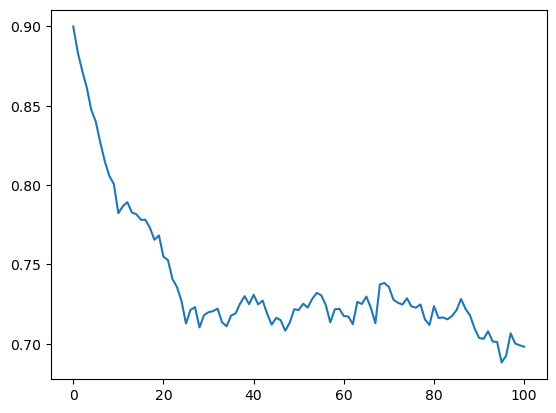

In [11]:
system = Harvest(1.0,0.2957516369929537,0.1)
t = system.computeTraj(100,0.1,0.9)

plt.plot(t)

## 4. Dynamic Optimal Control

Let's suppose now, that we want to control our system but we can change the value of $k$ at every time window. Taking as example the previous Harvest process, let's suppose to study it for 120 time units and we can change the value every 10 time units. We are applying in this situation a dynamic control based on a piece-wise constant function with independent value from one time window to another. To control this situation is almost the same idea as before but we need to do the optimization not on sets made of a single value but a vector of values. The idea per-se is a simple generalization of the Static one and we treat the different values a set of controllable parameters for our system however this makes everything more difficult for series of reasons:

1. **Computational Problems**: usually higher dimensionality spaces have a more complex morphology therefore it is often necessary to have more particles (speaking ina PSO framework) and more generations to converge in a value.
2. **Structural Problems of the Loss function**: there is a plethora of mathematical hypothesis below the euristic method which are very complex but the general idea is that this method are able to converge properly if the function presents enought variability in the loss value in comparison with the values of the parameters of the set. There could be some semi-flat region where the method is not able either to converge or find the best point.
3. **The Curse of Dimensionality**: strictly linked with the previous point, the euristic method does not work for any number of parameters. Most of them stops to works properly around 100 parameters. PSO is able to work until a number around 150. Over 200 there are almost no working general methods. The causes of this phenomena are several: one of them is the problem I told in the previous point. When you have tons of parameters at least some of them will be negligible in terms of impact on the loss in a certain locus of the parameters space. This loss of impact produces this kind of semi-flat region along certain direction of the space. The second main cause is linked to the information theory...
4. **"Why are too much? AI has much more!"**: this method for optimal control, even if they look similar, are very different from the optimizazion in Deep Learning. The main difference stays in the abscence of propagation method. When you are learning with an AI, you have the back propagation that makes something wonderful: given a discrepancy it can correct, thanks to the relationships and the structure, the values of the weights accordingly. Here we don't have that: the amount of the information given by the loss is simply "that combination gives this"; you cannot know where are you putting some error and it is actually impossible in a general case know that because it is linked both to the nature of the system and of the method. The only information that gives us is some kind of generic restriction (indication in comparison with a better results) which is very stochastical based. This small amount of information is sufficient in low dimensionalities but with more parameters the possibilities are simply too many in comparison with the restriction given by the results. It is very complex to explain properly and extremely theoretical.

Therefore most of the time if you want to have continuous value you opt to use some splines which allow to have different values at every time instant but with only some parameters required. Due to this reason we will try to work in a deterministic framework.

In our situation it is quite simple therefore there should be no issues. To continue we need first of all to adjust our loss function to be dependent by the different values of $k$.

$$
J=\int_0^T k(t)x(t)dt-\lambda\sum_{i=0}^{N_{win}}(k_i-k^*)
$$

It is probably not the best but for us is good. We need first of all to adjust our PSO manager on the different parts. The main things is that now we are in a multiD world thus all the update dynamics must be done vectorially.

In [83]:
class PSO_Manager(object):

    #CONSTRUCTOR
    def __init__(self,N: int,w: float,c1: float,c2: float)->None:
        #Let's check the input
        if(N<=0):
            raise RuntimeError("The number of particles must be positive.")
        if(w<0 or c1<0 or c2<0):
            raise RuntimeError("The parameters of the PSO must be non negative.")

        self._N = N
        self._w = w
        self._c1 = c1
        self._c2 = c2
        self._Nwin = 12 #ADD THE NUMBER OF REGIONS
        
        self.k_values = np.zeros((N,12),dtype=float)
        for i in range(self._N): #WE NEED TO CYCLE ALSO ON THE 12 REGIONS
            for j in range(self._Nwin):
                self.k_values[i,j] = random.uniform(0,0.5)
        self.pbest_values = copy.copy(self.k_values)
        self.v_values = np.zeros((N,12),dtype=float)

        #THIS STAYS THE SAME BECAUSE IT IS LINKED TO THE CONCEPT OF SET
        self.loss_values = -1e30*np.ones(N,dtype=float)

        self._lambda = 1
        self._k_star = 0.2

        self._var_counter = 0
        
        return

    #HERE WE NEED TO ADJUST TO MULTIPLY FOR THE CORRECT FACTOR!
    def computeLoss(self,T: np.array,index: int,h: float)->float:
        '''
        Given the trajectory, the index related to the k value
        and the step length, this function will compute the loss. 
        '''
        #First let's account the lambda effect
        loss = 0
        for i in range(self._Nwin):
            loss += self.k_values[index,i]-self._k_star

        loss *= -self._lambda

        #And then the integral
        I_val = 0
        counter = -1
        for i in range(len(T)): #The counter is need to keep track in which region are we
            if(i%10==0):
                counter += 1
            I_val += self.k_values[index,counter]*T[i]*h

        loss += I_val

        return loss

    def setLossValue(self,L: float,index: int)->None:
        '''
        Given the mean loss of a parameter value pointed by
        index, set the internal loss value associate as the input
        if it is better.
        '''
        if(L>=self.loss_values[index]):
            self.loss_values[index] = L
            self.pbest_values[index,:] = self.k_values[index,:] #WE NEED TO ADJUST TO THE VECTORIAL DYNAMIC HERE

        return
    
    def evolveValues(self)->None:
        '''
        Computed the loss values of a generation, this function will
        produce the new gen using the PSO update rules.
        '''
        gbest = np.argmax(self.loss_values)
        gbest = self.k_values[gbest,:] #VECTOR

        for i in range(self._N):
            self.v_values[i,:] = self._w*self.v_values[i,:] #VECTOR
            self.v_values[i,:] += self._c1*np.random.uniform(0,1,12)*(self.pbest_values[i,:]-self.k_values[i,:]) #VECTOR + RANDOM VECTOR (vec mult is already comp wise)
            self.v_values[i,:] += self._c2*np.random.uniform(0,1,12)*(gbest-self.k_values[i,:]) #VECTOR + RANDOM VECTOR
            self.k_values[i,:] += self.v_values[i,:] #VECTOR

        return

    #NOTHING TO DO HERE
    def exitCondition(self,index: int)->bool:
        '''
        Given the actual generation index, if enough generation passed,
        this system will check the variance condition and check if it
        is still valid.
        '''
        if(index<40):
            return True

        if(np.var(self.loss_values)/np.mean(self.loss_values)<=0.01):
            self._var_counter += 1

        if(self._var_counter==40):
            print("Exited through variance condition")
            return False

        if(index==300): #Max iteration exit
            print("Exited through maximum iteration")
            return False

        return True

Now we need to adjust also the Harvest class to use the correct $k$ value in the different moments.

In [84]:
class Harvest(object):

    #WE NEED TO PASS NOW K AS VECTOR
    def __init__(self,a: float,k: np.array)->None:
        if(a<0):
            raise RuntimeError("The alpha parameter must be non-negative.")
        #AND ADD A CHECK FOR K
        for i in range(len(k)):
            if(k[i]<0):
                raise RuntimeError("Each k value must be non-negative.")

        self._a = a
        self._k = k
        return

    #SAME THING HERE
    def setParam(self,a: float,k: np.array)->None:
        '''
        This function recieve new values for the parameters (a,k)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0):
            raise RuntimeError("The alpha parameter must be non-negative.")
        for i in range(len(k)):
            if(k[i]<0):
                raise RuntimeError("Each k value must be non-negative.")

        self._a = a
        self._k = k
        return

    #HERE WE NEED TO ADJUST TO USE THE CORRECT K
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''
        k = self._k[int((t_n/h)%10)]
        
        f = lambda x: self._a*x*(1-x)-k*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #WE DON'T HAVE TO CHANGE NOTHING HERE
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h)

        return traj

Now we can try to simulate and find the right set

In [91]:
Nsim = 150

pso = PSO_Manager(Nsim,0.6,0.1,0.1)
system = Harvest(1.0,np.zeros(12,dtype=float)) #the vector is a placeholder
gbest = -1e30

#GEN 0: loss estimation
for j in range(Nsim):
    losses = np.zeros(Nrep,dtype=float)
    system.setParam(1.0,pso.k_values[j,:])

    traj = system.computeTraj(119,0.1,0.9)
    L = pso.computeLoss(traj,j,0.1)

    #Compute the mean and pass it
    pso.setLossValue(L,j)


gen_counter = 0

while(pso.exitCondition(gen_counter)):
    #1. Evolve the set in the new points:
    pso.evolveValues()
    
    #2. Compute the new losses
    for j in range(Nsim):
        losses = np.zeros(Nrep,dtype=float)
        system.setParam(1.0,pso.k_values[j,:])

        traj = system.computeTraj(119,0.1,0.9)
        L = pso.computeLoss(traj,j,0.1)
    
        #Compute the mean and pass it
        pso.setLossValue(L,j)

    gen_counter += 1

Exited through variance condition


In [92]:
index = np.argmax(pso.loss_values)
print(pso.k_values[index,:])

[0.16467875 0.28951366 0.16147617 0.08823734 0.04034506 0.08414121
 0.28174092 0.1308166  0.11175227 0.10986642 0.10752119 0.21849421]


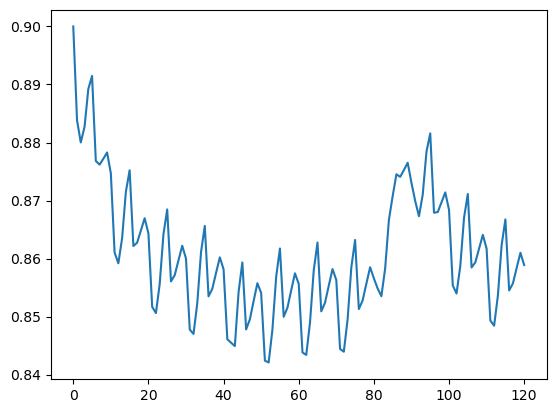

In [93]:
system = Harvest(1.0,pso.k_values[index,:])
t = system.computeTraj(120,0.1,0.9)

plt.plot(t)

And here it is. As you can notice the system starts to alternate one region after the other exploiting some patterns based on peaks and counter-peaks (BANG-BANG BEHAVIOUR). If you repeat multiple times you will find multiple results that can be caused by two possible things: not enough simulation (or other method problems) multiple similarly good solution. Maybe also changing the exit method to something more stable (such as stagnation) could help improve to obtaining the same set every time. 